# ❄️ Snow Water Equivalent Reconstruction

<center>
  <img src="images/15Advanced_LTC2026_KV_final.png" width="60%">
</center>

**Course website:**  
https://eo4society.esa.int/event/15th-advanced-training-course-on-land-remote-sensing-the-water-cycle/

**Instructors:** Carlo Marin and Valentina Premier, Eurac Research

---
## Overview

In this notebook, you will reconstruct **Snow Water Equivalent (SWE)** over the Lo Aguirre study area. You will learn about the meteorological inputs and remote sensing data needed for SWE reconstruction, become familiar with the **Enhanced Temperature Index (ETI) model**, and explore the sensitivity of the main parameters that are typically tuned during SWE reconstruction.

The workflow follows the approach presented by [Premier et al. (2023)](https://tc.copernicus.org/articles/17/2387/2023/).

## Learning Objectives

By the end of this notebook, you will be able to:

* Understand the input data required for SWE reconstruction.
* Become familiar with the **Enhanced Temperature Index (ETI) model**.
* Explore the sensitivity of the model to different parameter values.
* Tune the **temperature and radiation factors** used for SWE reconstruction.

---

## 1. Setup

First, run the import cell below.

If you receive a `ModuleNotFoundError`:

1. uncomment and run the installation cell;
2. restart the kernel;
3. run the notebook again from the beginning.

If all imports work, skip the installation cell.

In [65]:
# %pip install pystac-client stackstac xarray dask pandas matplotlib

In [66]:
from pathlib import Path
import sys
import time
import matplotlib.pyplot as plt
import leafmap
import numpy as np

import pandas as pd
import stackstac
import xarray as xr
import rioxarray as rxr
from pystac_client import Client

# Locate the repository and tutorial-data folders.
WORKDIR = Path.cwd()
ROOT = WORKDIR.parent
TUTORIAL_DIR = ROOT / "eotraining"

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(TUTORIAL_DIR))

from melting import (
    compute_state_and_accumulation,
    get_melt_pomeroy,
    get_swe,
)


def load_stac_cube(data, label, max_attempts=3):
    """Compute a STAC cube, retrying transient HTTP tile-read failures."""
    for attempt in range(1, max_attempts + 1):
        try:
            scheduler = None if attempt == 1 else "single-threaded"
            return data.compute(scheduler=scheduler)
        except RuntimeError as error:
            is_tile_error = "Error reading Window" in str(error)
            if not is_tile_error or attempt == max_attempts:
                raise
            delay = 2 ** (attempt - 1)
            print(
                f"Transient read error while loading {label}; "
                f"retrying in {delay} s ({attempt}/{max_attempts})"
            )
            time.sleep(delay)

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
})

## 2. Select a hydrological year

In this Southern Hemisphere exercise, a hydrological year starts on **1 April** and ends on **31 March** of the following calendar year. For this tutorial, we have prepared data covering the season 2022/23.

In [67]:
HY_START_YEAR = 2022  # Selects 2022-04-01 through 2023-03-31

DATE_START = f"{HY_START_YEAR}-04-01"
DATE_END = f"{HY_START_YEAR + 1}-03-31"

HYDROLOGICAL_YEAR = f"HY{HY_START_YEAR}/{HY_START_YEAR + 1}"

print(f"Selected {HYDROLOGICAL_YEAR}: {DATE_START} to {DATE_END}")

Selected HY2022/2023: 2022-04-01 to 2023-03-31


In [68]:
DEM_PATH = TUTORIAL_DIR / "DEM.tif"

dem = (
  rxr.open_rasterio(DEM_PATH, masked=True)
  .squeeze("band", drop=True)
  .rename("elevation")
)

EXTENT = dem.rio.bounds()
RESOLUTION = dem.rio.resolution()
EPSG = dem.rio.crs.to_epsg()

## 3. Load temperature from STAC

We query only the dates in the selected hydrological year. Each STAC Item contains one daily, 50 m Cloud-Optimized GeoTIFF named `t2m`. `stackstac` combines the returned Items into a lazy `(time, y, x)` data cube over the Lo Aguirre study-area footprint.

In [69]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
TEMPERATURE_COLLECTION = "LoAguirre_temperature"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[TEMPERATURE_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

temperature = (
  stackstac.stack(
      items,
      assets=["t2m"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

temperature

Found 365 items


<xarray.DataArray 'stackstac-c308dcfb5130a916d5c848cc30a3f80a' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    ...                   ...
    epsg                 int64 8B 32719
    wkt2                 <U605 2kB 'PROJCS["WGS 84 / UTM zone 19S",GEOGCS["WG...
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

### Load the raster values

The previous cell created a **lazy data cube** containing only the instructions needed to read each scene.

The following cell downloads the pixel values because the conditional-probability calculations require the 

In [48]:
temperature = load_stac_cube(
    temperature.astype("float32"), "temperature"
)

print("Dimensions:", dict(temperature.sizes))
print(f"Memory used: {temperature.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


### Mean temperature over the study area

The STAC cube above is lazy. The next cell reads the selected COGs and calculates one spatial mean for each day. The dashed line shows the mean over the entire hydrological year.

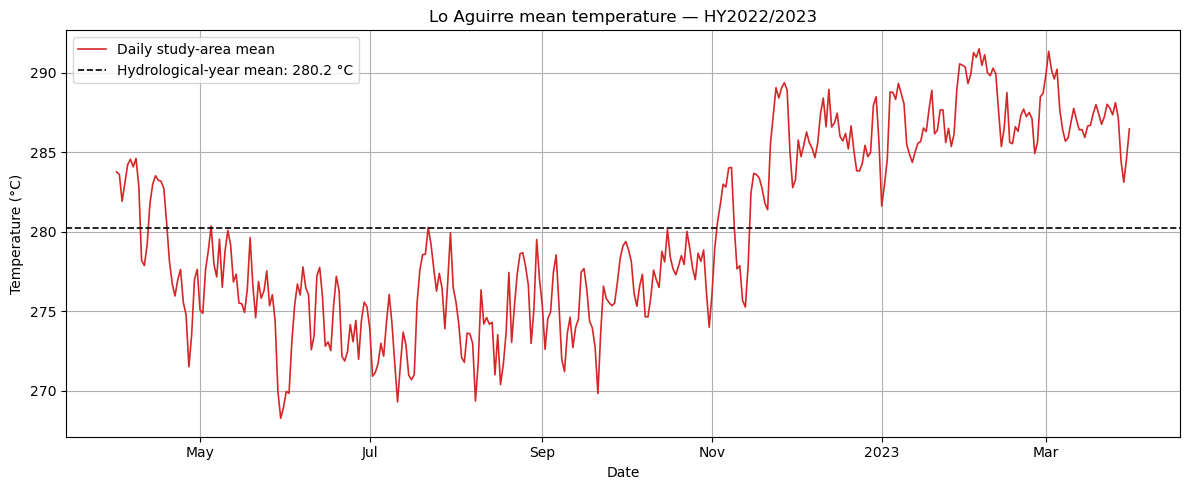

Mean temperature over HY2022/2023: 280.22 °C


In [49]:
area_mean_temperature = (
    temperature
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)
hydrological_year_mean = float(area_mean_temperature.mean().item())

fig, ax = plt.subplots()
area_mean_temperature.plot(
    ax=ax,
    color="tab:red",
    linewidth=1.2,
    label="Daily study-area mean",
)
ax.axhline(
    hydrological_year_mean,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Hydrological-year mean: {hydrological_year_mean:.1f} °C",
)
ax.set(
    title=f"Lo Aguirre mean temperature — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Temperature (°C)",
)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean temperature over {HYDROLOGICAL_YEAR}: {hydrological_year_mean:.2f} °C")

In [50]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
SW_COLLECTION = "LoAguirre_SW"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[SW_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

SW = (
  stackstac.stack(
      items,
      assets=["SW"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

SW

Found 365 items


<xarray.DataArray 'stackstac-d1d2d06a94095a263c57b03e7306d50d' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    ...                   ...
    epsg                 int64 8B 32719
    wkt2                 <U605 2kB 'PROJCS["WGS 84 / UTM zone 19S",GEOGCS["WG...
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

In [51]:
SW = load_stac_cube(SW.astype("float32"), "shortwave radiation")

print("Dimensions:", dict(SW.sizes))
print(f"Memory used: {SW.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


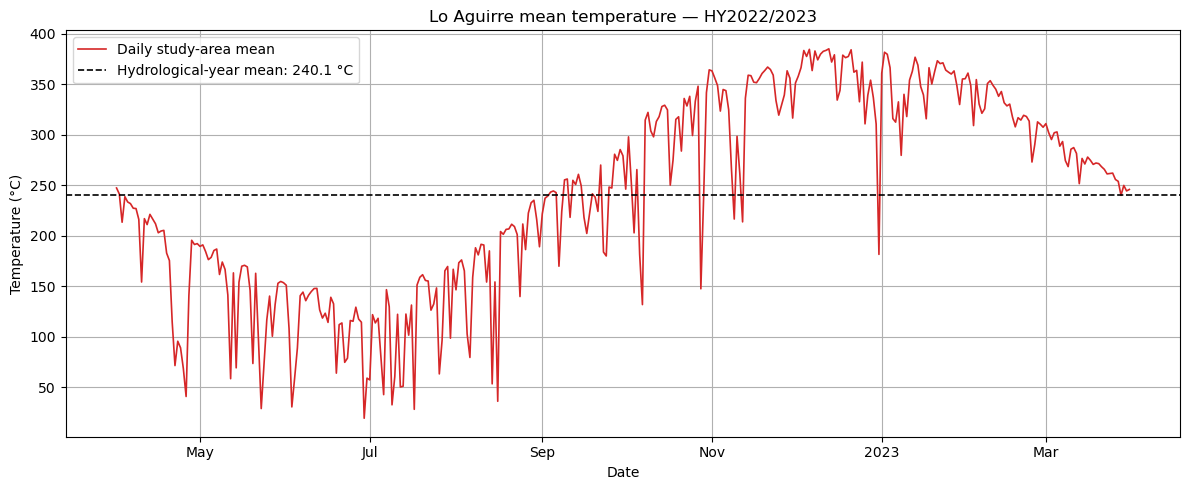

Mean temperature over HY2022/2023: 240.12 °C


In [52]:
area_mean_SW = (
    SW
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)
hydrological_year_mean = float(area_mean_SW.mean().item())

fig, ax = plt.subplots()
area_mean_SW.plot(
    ax=ax,
    color="tab:red",
    linewidth=1.2,
    label="Daily study-area mean",
)
ax.axhline(
    hydrological_year_mean,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Hydrological-year mean: {hydrological_year_mean:.1f} °C",
)
ax.set(
    title=f"Lo Aguirre mean temperature — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Temperature (°C)",
)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Mean temperature over {HYDROLOGICAL_YEAR}: {hydrological_year_mean:.2f} °C")

In [53]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
PRECIPITATION_COLLECTION = "LoAguirre_precipitation"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[PRECIPITATION_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

precipitation = (
  stackstac.stack(
      items,
      assets=["tp"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

precipitation

Found 365 items


<xarray.DataArray 'stackstac-f878611fb37cb732aedb8bd38ec1c51b' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    shape                object 8B {9}
    bbox                 object 8B {-71.0500000000028, -70.15000000000259, -3...
    ...                   ...
    epsg                 int64 8B 32719
    wkt2                 <U302 1kB 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID...
    transform            object 8B {0.10000000000002274, 0.0, -0.100000000000...
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

In [54]:
precipitation = load_stac_cube(
    precipitation.astype("float32"), "precipitation"
)

print("Dimensions:", dict(precipitation.sizes))
print(f"Memory used: {precipitation.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


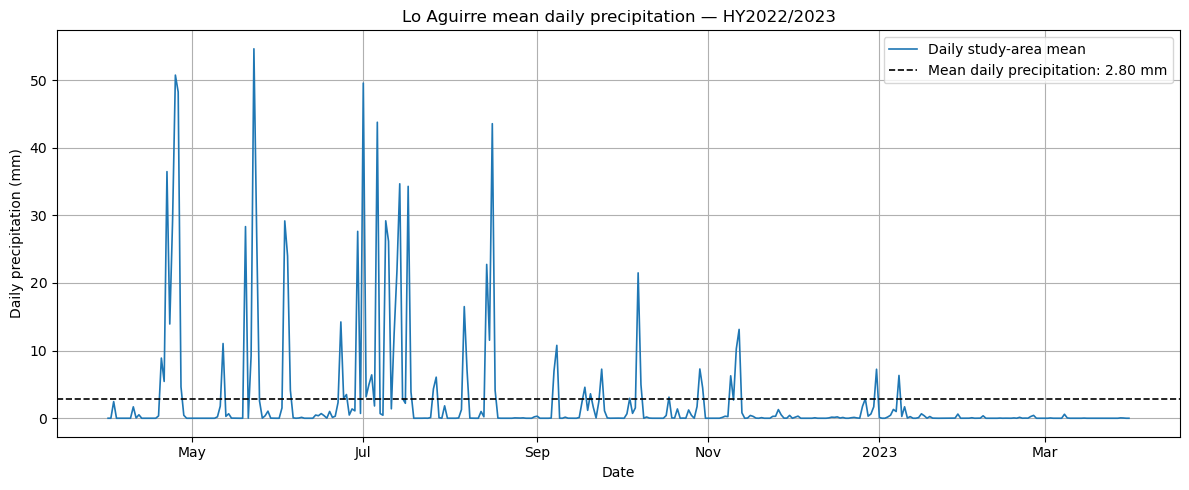

Total precipitation over HY2022/2023: 1022.7 mm


In [55]:
area_mean_precipitation = (
    precipitation
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)
mean_daily_precipitation = float(area_mean_precipitation.mean().item())
hydrological_year_precipitation = float(area_mean_precipitation.sum().item())

fig, ax = plt.subplots()
area_mean_precipitation.plot(
    ax=ax,
    color="tab:blue",
    linewidth=1.2,
    label="Daily study-area mean",
)
ax.axhline(
    mean_daily_precipitation,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Mean daily precipitation: {mean_daily_precipitation:.2f} mm",
)
ax.set(
    title=f"Lo Aguirre mean daily precipitation — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Daily precipitation (mm)",
)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f"Total precipitation over {HYDROLOGICAL_YEAR}: "
    f"{hydrological_year_precipitation:.1f} mm"
)

In [56]:
STAC_API = "https://stac.openeo.eurac.edu/api/v1/pgstac/"
SCA_COLLECTION = "LoAguirre_daily_sca"


catalog = Client.open(STAC_API)

items = catalog.search(
  collections=[SCA_COLLECTION],
  datetime=f"{DATE_START}/{DATE_END}",
).item_collection()

print(f"Found {len(items)} items")

if not items:
    raise ValueError(
        f"No daily SCA items are currently published for {HYDROLOGICAL_YEAR}"
    )

SCA = (
  stackstac.stack(
      items,
      assets=["SCA"],
      epsg=EPSG,
      resolution=RESOLUTION[0],
      bounds=EXTENT,
      xy_coords="center",
  )
  .squeeze("band", drop=True)
  .sortby("time")
)

SCA

Found 365 items


<xarray.DataArray 'stackstac-6b9a0999252c027820d4cdd598fdbe79' (time: 365,
                                                                y: 400, x: 400)> Size: 467MB
dask.array<getitem, shape=(365, 400, 400), dtype=float64, chunksize=(1, 400, 400), chunktype=numpy.ndarray>
Coordinates: (12/14)
  * time                 (time) datetime64[ns] 3kB 2022-04-01 ... 2023-03-31
  * y                    (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06
  * x                    (x) float64 3kB 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
    id                   (time) <U14 20kB '20220401000000' ... '20230331000000'
    shape                object 8B {400}
    bbox                 object 8B {354000.0, 362000.0, 6014000.0, 6022000.0}
    ...                   ...
    epsg                 int64 8B 32719
    wkt2                 <U605 2kB 'PROJCS["WGS 84 / UTM zone 19S",GEOGCS["WG...
    transform            object 8B {0.0, 1.0, -20.0, 6022000.0, 354000.0, 20.0}
    common_name          object 8B None
    center_wavelength    object 8B None
    full_width_half_max  object 8B None
Attributes:
    spec:        RasterSpec(epsg=32719, bounds=(354000.0, 6014000.0, 362000.0...
    crs:         epsg:32719
    transform:   | 20.00, 0.00, 354000.00|\n| 0.00,-20.00, 6022000.00|\n| 0.0...
    resolution:  20.0

In [57]:
SCA = load_stac_cube(SCA.astype("float32"), "daily SCA")

print("Dimensions:", dict(SCA.sizes))
print(f"Memory used: {SCA.nbytes / 1e6:.1f} MB")

Dimensions: {'time': 365, 'y': 400, 'x': 400}
Memory used: 233.6 MB


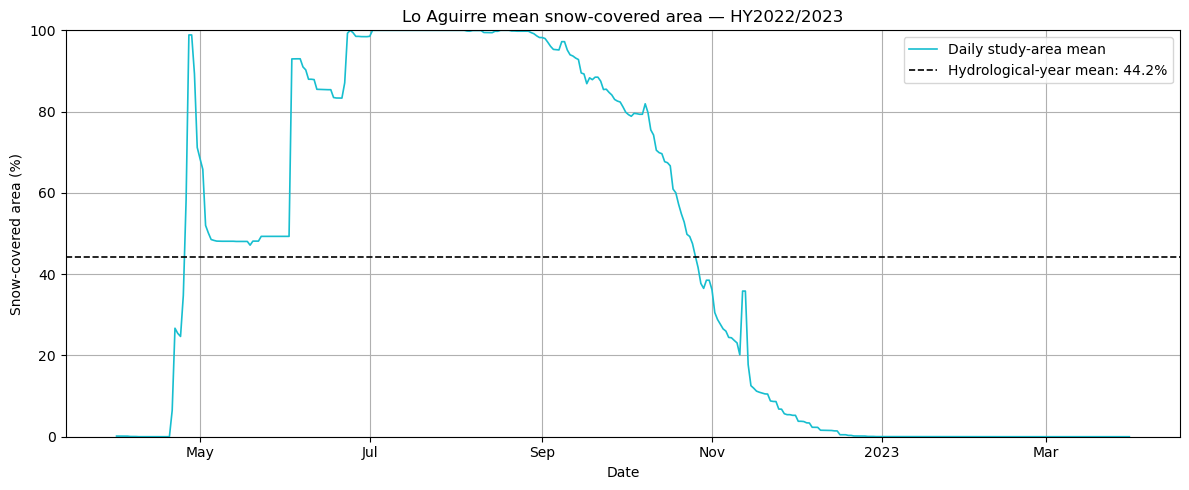

Mean SCA over HY2022/2023: 44.21%


In [58]:
valid_SCA = SCA.where((SCA >= 0) & (SCA <= 100))

area_mean_SCA = (
    valid_SCA
    .mean(dim=("y", "x"), skipna=True)
    .compute()
)
hydrological_year_mean_SCA = float(area_mean_SCA.mean().item())

fig, ax = plt.subplots()
area_mean_SCA.plot(
    ax=ax,
    color="tab:cyan",
    linewidth=1.2,
    label="Daily study-area mean",
)
ax.axhline(
    hydrological_year_mean_SCA,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Hydrological-year mean: {hydrological_year_mean_SCA:.1f}%",
)
ax.set(
    title=f"Lo Aguirre mean snow-covered area — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="Snow-covered area (%)",
    ylim=(0, 100),
)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f"Mean SCA over {HYDROLOGICAL_YEAR}: "
    f"{hydrological_year_mean_SCA:.2f}%"
)

## 4. SWE reconstruction: melt-factor sensitivity

We now reproduce the core workflow in `main.py` using the four arrays loaded from STAC. The model infers accumulation and melt periods from temperature and precipitation, computes potential melt from a temperature-index term and a shortwave-radiation term, and reconstructs SWE constrained by the observed SCA transitions.

The potential melt is controlled by two parameters:

- `TF`: temperature or degree-day factor;
- `SRF`: shortwave-radiation factor.

This is a **sensitivity experiment**, not a calibration: parameter values should normally be evaluated against independent SWE observations. The `get_melt_pomeroy` implementation used by `main.py` also imposes zero melt during the first 122 days of the hydrological year. We retain that rule here so the notebook reproduces the current model behavior.

### Prepare the STAC inputs

All four STAC cubes were loaded on the DEM grid. We retain only their dimension coordinates, align their common dates, convert temperature from Kelvin to degrees Celsius, and give each array the variable name expected by the reconstruction functions.

In [59]:
def model_array(data, name):
    """Keep dimension coordinates and assign the model variable name."""
    return data.reset_coords(drop=True).rename(name)


# Materialize inputs here as well. This keeps the reconstruction section
# safe if a STAC query cell was rerun after its earlier loading cell.
SCA_input = model_array(load_stac_cube(SCA, "daily SCA"), "SCA")
temperature_input = model_array(
    load_stac_cube(temperature, "temperature"), "t2m"
)
SW_input = model_array(
    load_stac_cube(SW, "shortwave radiation"), "SW"
)
precipitation_input = model_array(
    load_stac_cube(precipitation, "precipitation"), "tp"
)

SCA_input, temperature_input, SW_input, precipitation_input = xr.align(
    SCA_input,
    temperature_input,
    SW_input,
    precipitation_input,
    join="inner",
)

expected_days = (pd.Timestamp(DATE_END) - pd.Timestamp(DATE_START)).days + 1
if SCA_input.sizes["time"] != expected_days:
    raise ValueError(
        f"Expected {expected_days} common daily observations, found "
        f"{SCA_input.sizes['time']}"
    )

temperature_input = temperature_input - 273.15
temperature_input.attrs["units"] = "°C"

SCA_model = SCA_input.to_dataset(name="SCA")
temperature_model = temperature_input.to_dataset(name="t2m")
SW_model = SW_input.to_dataset(name="SW")
if not (
    np.array_equal(SCA_input.x.values, dem.x.values)
    and np.array_equal(SCA_input.y.values, dem.y.values)
):
    raise ValueError("The STAC and DEM pixel-centre coordinates do not match")

domain_mask = dem.notnull().reset_coords(drop=True)

print("Model dimensions:", dict(SCA_model.sizes))
print("Temperature units:", temperature_input.attrs["units"])
print("Precipitation units: mm/day")
print("Shortwave-radiation units: W m⁻²")

Model dimensions: {'time': 365, 'x': 400, 'y': 400}
Temperature units: °C
Precipitation units: mm/day
Shortwave-radiation units: W m⁻²


### Identify accumulation and melt conditions

Following the current reconstruction code, a pixel is classified as accumulating when daily temperature is below 2 °C and precipitation exceeds 10 mm. The normalized precipitation fraction `delta` distributes the inferred accumulation through time. Since the STAC precipitation cube is already on the SCA grid, no additional reprojection is needed here.

In [60]:
ACCUMULATION_TEMPERATURE = 2.0  # °C
PRECIPITATION_THRESHOLD = 2.0  # mm/day

status = xr.where(
    (temperature_input < ACCUMULATION_TEMPERATURE)
    & (precipitation_input > PRECIPITATION_THRESHOLD),
    1,
    -1,
).astype("int8")

accumulation_precipitation = precipitation_input.where(status == 1)
total_accumulation = accumulation_precipitation.sum(dim="time")
delta = (
    accumulation_precipitation
    / total_accumulation.where(total_accumulation > 0)
).fillna(0).astype("float32")

status = status.load()
delta = delta.load()

accumulation_fraction = float((status == 1).mean().item())
print(f"Accumulation conditions: {accumulation_fraction:.1%} of pixel-days")

Accumulation conditions: 8.8% of pixel-days


### Define and run melt-factor scenarios

The middle scenario contains the factors used in `main.py`. Change the values below, add another scenario, or remove one and rerun the cells to explore model sensitivity. To limit memory use, the notebook retains only the spatial-mean SWE series and the SWE map at each scenario's peak date.

In [61]:
import contextlib
import gc
import io
from time import perf_counter


MELT_SCENARIOS = {
    "Low melt": {"TF": 0.18, "SRF": 0.10},
    "Reference": {"TF": 0.24, "SRF": 0.15},
    "High melt": {"TF": 0.30, "SRF": 0.20},
}

scenario_results = {}
scenario_summary = []

for scenario, factors in MELT_SCENARIOS.items():
    started = perf_counter()
    print(
        f"Running {scenario}: TF={factors['TF']}, "
        f"SRF={factors['SRF']}"
    )

    # The model functions print every processed date; suppress those messages
    # here so that scenario-level progress remains readable.
    with contextlib.redirect_stdout(io.StringIO()):
        melt = get_melt_pomeroy(
            SCA_model,
            temperature_model,
            precipitation_input,
            SW_model,
            status,
            TF=factors["TF"],
            SRF=factors["SRF"],
            T_thresh=0.0,
        )
        sca_sum, total_melt = compute_state_and_accumulation(
            SCA_model, melt, status, delta
        )
        swe_values = get_swe(
            SCA_model, melt, status, delta, sca_sum, total_melt
        )

    SWE = xr.DataArray(
        swe_values,
        dims=("time", "y", "x"),
        coords={
            "time": SCA_input.time,
            "y": SCA_input.y,
            "x": SCA_input.x,
        },
        name="SWE",
        attrs={"units": "mm"},
    ).where(domain_mask)

    mean_SWE = SWE.mean(dim=("y", "x"), skipna=True)
    if bool(mean_SWE.isnull().all().item()):
        raise ValueError(
            "The reconstructed SWE contains no valid study-area pixels. "
            "Check the SCA values and spatial-grid coordinates."
        )
    peak_index = int(mean_SWE.argmax(skipna=True).item())
    peak_date = pd.Timestamp(SWE.time.isel(time=peak_index).values)
    peak_mean_SWE = float(mean_SWE.isel(time=peak_index).item())

    scenario_results[scenario] = {
        "mean_SWE": mean_SWE.copy(),
        "peak_map": SWE.isel(time=peak_index, drop=True).copy(),
        "peak_date": peak_date,
    }
    scenario_summary.append({
        "Scenario": scenario,
        "TF": factors["TF"],
        "SRF": factors["SRF"],
        "Peak date": peak_date.date(),
        "Peak mean SWE (mm)": peak_mean_SWE,
    })

    del melt, sca_sum, total_melt, swe_values, SWE
    gc.collect()
    print(f"Completed in {perf_counter() - started:.1f} seconds")

pd.DataFrame(scenario_summary).set_index("Scenario").round(2)

Running Low melt: TF=0.18, SRF=0.1
Completed in 4.9 seconds
Running Reference: TF=0.24, SRF=0.15
Completed in 4.7 seconds
Running High melt: TF=0.3, SRF=0.2
Completed in 4.7 seconds


,TF,SRF,Peak date,Peak mean SWE (mm)
Scenario,,,,
Low melt,0.18,0.10,2022-08-17,407.94
Reference,0.24,0.15,2022-08-17,606.14
High melt,0.30,0.20,2022-08-17,804.33


In [40]:
SCA_model


<xarray.Dataset> Size: 234MB
Dimensions:  (time: 365, x: 400, y: 400)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2022-04-01 2022-04-02 ... 2023-03-31
  * x        (x) float64 3kB 3.54e+05 3.54e+05 3.54e+05 ... 3.62e+05 3.62e+05
  * y        (y) float64 3kB 6.022e+06 6.022e+06 ... 6.014e+06 6.014e+06
Data variables:
    SCA      (time, y, x) float32 234MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Compare the reconstructed SWE

First compare the daily study-area mean SWE. Then compare the spatial pattern on the peak-SWE date identified separately for each scenario. All maps share one colour scale.

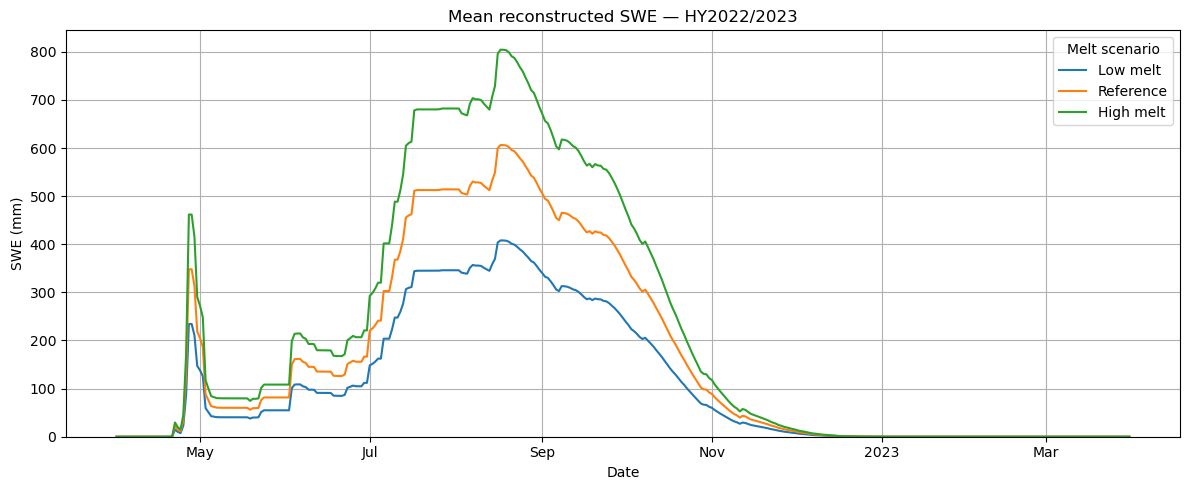

In [62]:
fig, ax = plt.subplots()

for scenario, result in scenario_results.items():
    result["mean_SWE"].plot(
        ax=ax,
        linewidth=1.5,
        label=scenario,
    )

ax.set(
    title=f"Mean reconstructed SWE — {HYDROLOGICAL_YEAR}",
    xlabel="Date",
    ylabel="SWE (mm)",
)
ax.set_ylim(bottom=0)
ax.legend(title="Melt scenario")
fig.tight_layout()
plt.show()

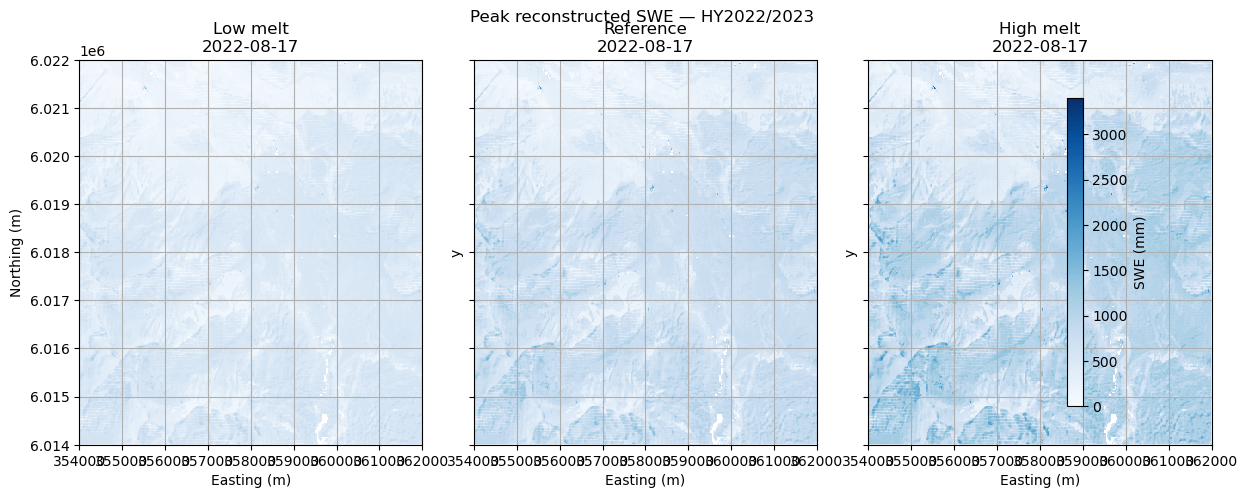

In [64]:
peak_maps = [result["peak_map"] for result in scenario_results.values()]
shared_vmax = max(float(peak_map.max(skipna=True).item()) for peak_map in peak_maps)
shared_vmax = max(shared_vmax, 1.0)

fig, axes = plt.subplots(
    1,
    len(scenario_results),
    figsize=(5 * len(scenario_results), 5),
    sharex=True,
    sharey=True,
)
axes = np.atleast_1d(axes)

for ax, (scenario, result) in zip(axes, scenario_results.items()):
    image = result["peak_map"].plot.imshow(
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=shared_vmax,
        add_colorbar=False,
    )
    ax.set_title(
        f"{scenario}\n{result['peak_date']:%Y-%m-%d}"
    )
    ax.set_xlabel("Easting (m)")

axes[0].set_ylabel("Northing (m)")
fig.colorbar(image, ax=axes.tolist(), label="SWE (mm)", shrink=0.8)
fig.suptitle(f"Peak reconstructed SWE — {HYDROLOGICAL_YEAR}", y=0.98)
fig.subplots_adjust(wspace=0.15, right=0.88)
plt.show()

### Questions for students

1. Which factor has the strongest influence on peak SWE: `TF` or `SRF`? Change one factor at a time to find out.
2. Do the factors change only the magnitude of SWE, or also the date of peak SWE?
3. Where are the spatial differences between scenarios largest, and how do they relate to elevation?
4. Why is parameter sensitivity not the same as model calibration? What independent observations would you use for calibration and validation?
5. How might the hard-coded 122-day no-melt period affect the interpretation of the results?